# 🛰️ Thermal-Edge-Fire: Pan-African Exploratory Data Analysis (EDA)
### Onboard Thermal/IR Edge-Computing for Wildfire Detection on a 6U CubeSat

This notebook provides an interactive **Exploratory Data Analysis (EDA)** of satellite thermal imagery over the African continent, focusing on:
1. **Geographic Distribution**: North Africa / Mediterranean Basin (Tunisia / Maghreb) vs. Sub-Saharan Africa.
2. **Thermal Channel Visualizations**: Landsat-8 TIRS Band 10 (10.9 µm LWIR) and Band 11 (12.0 µm LWIR).
3. **Physical Fire Separability**: Radiant intensity elevation of active fire fronts above hot desert/savanna backgrounds.
4. **Gate 1 Validation Quality Gate**: Pre-treatment sensor telemetry verification (Ground Mode vs. Flight PSF Halo Mode).
5. **Dataset Quality Summary**: Mask coverage statistics and data health.


In [1]:
import sys
from pathlib import Path

# Add project src/ to sys.path so fireedge package is importable
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from fireedge.config import load_config, resolve_path, get_reports_dir
from fireedge.io import read_image, read_mask, index_patches
from fireedge.validation import GroundGateValidator, FlightGateValidator, ValidatorConfig

# Use a clean plot style
_style = 'seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default'
plt.style.use(_style)
%matplotlib inline
print(f"Environment initialized successfully.")
print(f"  Project root: {PROJECT_ROOT}")
print(f"  Python: {sys.executable}")
print(f"  NumPy: {np.__version__}")

Environment initialized successfully.
  Project root: C:\Users\Dell\Desktop\GeoAI\IASTAM\thermal-edge-fire
  Python: C:\Python314\python.exe
  NumPy: 2.3.5


## 1. African Dataset Inventory & Geolocation
We load the curated African inventory (`reports/africa_inventory.csv`) derived from Pereira et al. (ActiveFire).
Each scene has been inverse-projected from UTM projection coordinates to geographic WGS84 (${\rm Lat}, {\rm Lon}$).


In [2]:
reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)
inv_path = reports_dir / "africa_inventory.csv"

if not inv_path.exists():
    print("Generating inventory from ActiveFire root...")
    cfg = load_config(PROJECT_ROOT / "configs" / "config.yaml")
    data_root = resolve_path(cfg["data"]["activefire_root"])
    df_all = index_patches(data_root)
    df_africa = df_all[df_all["region"].isin(["NORTH_AFRICA_MED", "SUB_SAHARAN_AFRICA"])].copy()
    df_africa.to_csv(inv_path, index=False)
    print(f"  Saved {len(df_africa)} African scenes to {inv_path}")
else:
    df_africa = pd.read_csv(inv_path)
    print(f"  Loaded cached inventory: {inv_path}")

print(f"\nTotal African Scenes: {len(df_africa)}")
print(f"  With fire mask: {df_africa['has_mask'].sum()}")
print(f"  Without mask:   {(~df_africa['has_mask']).sum()}")
print("\nRegional Distribution:")
display(df_africa["region"].value_counts().to_frame("Count"))

  Loaded cached inventory: C:\Users\Dell\Desktop\GeoAI\IASTAM\thermal-edge-fire\reports\africa_inventory.csv

Total African Scenes: 44
  With fire mask: 44
  Without mask:   0

Regional Distribution:


,Count
region,
SUB_SAHARAN_AFRICA,39
NORTH_AFRICA_MED,5


<ipython-input-1-cf0dd8ee87cb>:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


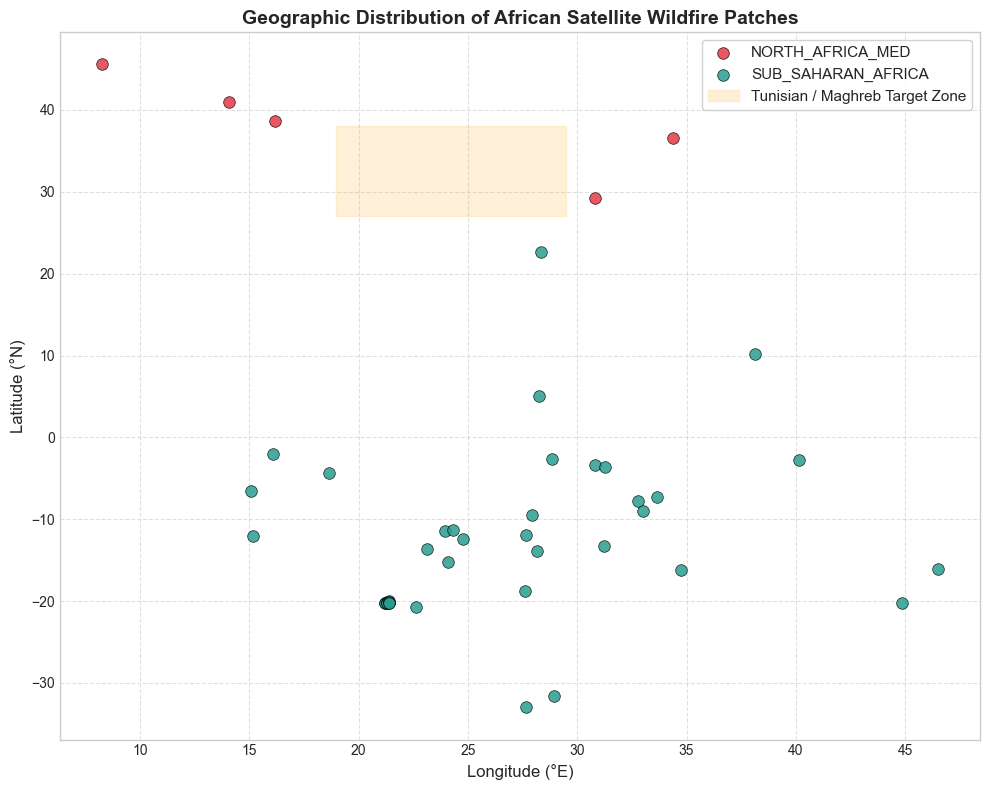

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot of African scenes by region
colors = {"NORTH_AFRICA_MED": "#E63946", "SUB_SAHARAN_AFRICA": "#2A9D8F"}
for region, group in df_africa.groupby("region"):
    ax.scatter(group["center_lon"], group["center_lat"], 
               c=colors.get(region, "#457B9D"), label=region, s=70, alpha=0.85, edgecolors='black', linewidth=0.5)

# Highlight Tunisia / North Africa target area
ax.axhspan(27, 38, xmin=0.3, xmax=0.55, color='orange', alpha=0.15, label='Tunisian / Maghreb Target Zone')

ax.set_title("Geographic Distribution of African Satellite Wildfire Patches", fontsize=14, weight='bold')
ax.set_xlabel("Longitude (°E)", fontsize=12)
ax.set_ylabel("Latitude (°N)", fontsize=12)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(frameon=True, facecolor="white", framealpha=0.9, fontsize=11)

plt.tight_layout()
plt.show()

## 2. Multi-Channel Thermal Inspection
Here we visualize a representative African wildfire patch across:
- **Band 10 (10.9 µm LWIR)**: Primary thermal channel for microbolometer CubeSat payload.
- **Band 11 (12.0 µm LWIR)**: Secondary thermal channel for ground-truth cross-confirmation.
- **Thermal Difference $(B10 - B11)$**: Differential absorption highlighting smoke and active fire emissivity.
- **Voting Fire Mask**: Human & multi-algorithm consensus active fire ground truth.


<ipython-input-1-76ffd304ac25>:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


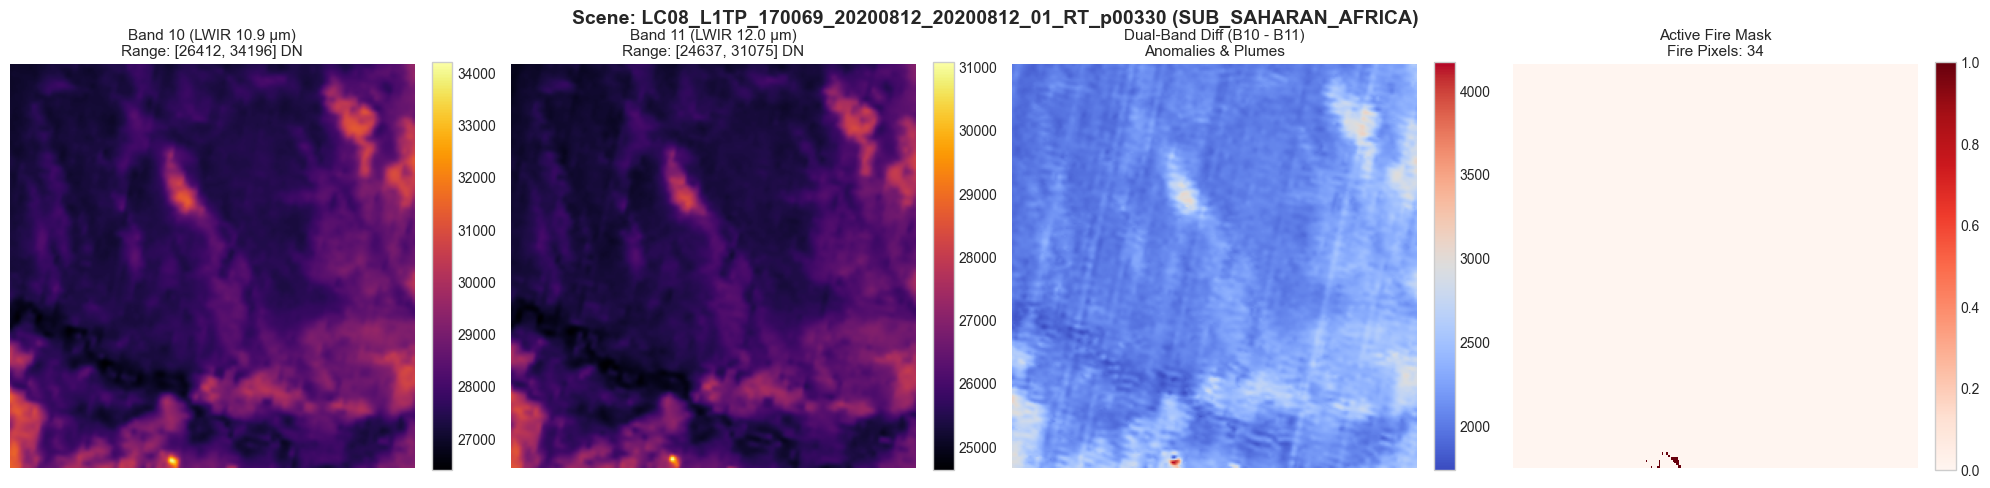

In [4]:
# Pick a sample patch with active fire
fire_patches = df_africa[df_africa["has_mask"]]
if len(fire_patches) == 0:
    print("WARNING: No patches with fire masks found. Skipping visualization.")
else:
    sample_idx = min(10, len(fire_patches) - 1)
    sample_row = fire_patches.iloc[sample_idx]

    img = read_image(sample_row["image_path"])
    mask = read_mask(sample_row["mask_path"], shape=img.shape[1:])

    n_bands = img.shape[0]
    b10_idx = min(8, n_bands - 1)
    b11_idx = min(9, n_bands - 1)

    b10 = img[b10_idx]
    b11 = img[b11_idx]
    b10_sub_b11 = b10.astype(float) - b11.astype(float)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    im0 = axes[0].imshow(b10, cmap="inferno")
    axes[0].set_title(f"Band 10 (LWIR 10.9 µm)\nRange: [{b10.min()}, {b10.max()}] DN", fontsize=11)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(b11, cmap="inferno")
    axes[1].set_title(f"Band 11 (LWIR 12.0 µm)\nRange: [{b11.min()}, {b11.max()}] DN", fontsize=11)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(b10_sub_b11, cmap="coolwarm")
    axes[2].set_title(f"Dual-Band Diff (B10 - B11)\nAnomalies & Plumes", fontsize=11)
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(mask, cmap="Reds", interpolation="nearest")
    axes[3].set_title(f"Active Fire Mask\nFire Pixels: {int((mask > 0).sum())}", fontsize=11)
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    for ax in axes:
        ax.axis("off")

    plt.suptitle(f"Scene: {sample_row['stem']} ({sample_row['region']})", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

## 3. Physical Thermal Separability Analysis
In John McDonald's feedback (§6.3), a critical question is whether thermal-only LWIR data is sufficient to detect wildfires without false alarms on hot bare ground.
Below, we evaluate the Digital Number (DN) distribution of **active fire pixels** versus **background land pixels** across all African scenes.


=== African Separability Summary ===


<ipython-input-1-fcb25d05b94d>:49: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,band,fire_pixels,bg_pixels,fisher_ratio,auc_score,ks_statistic,ks_pvalue
2,B7,4840,55496,5.2243,0.9962,0.9617,0.0
0,B10,4840,55496,1.2679,0.9678,0.8480,0.0
1,B11,4840,55496,1.1276,0.9597,0.8166,0.0


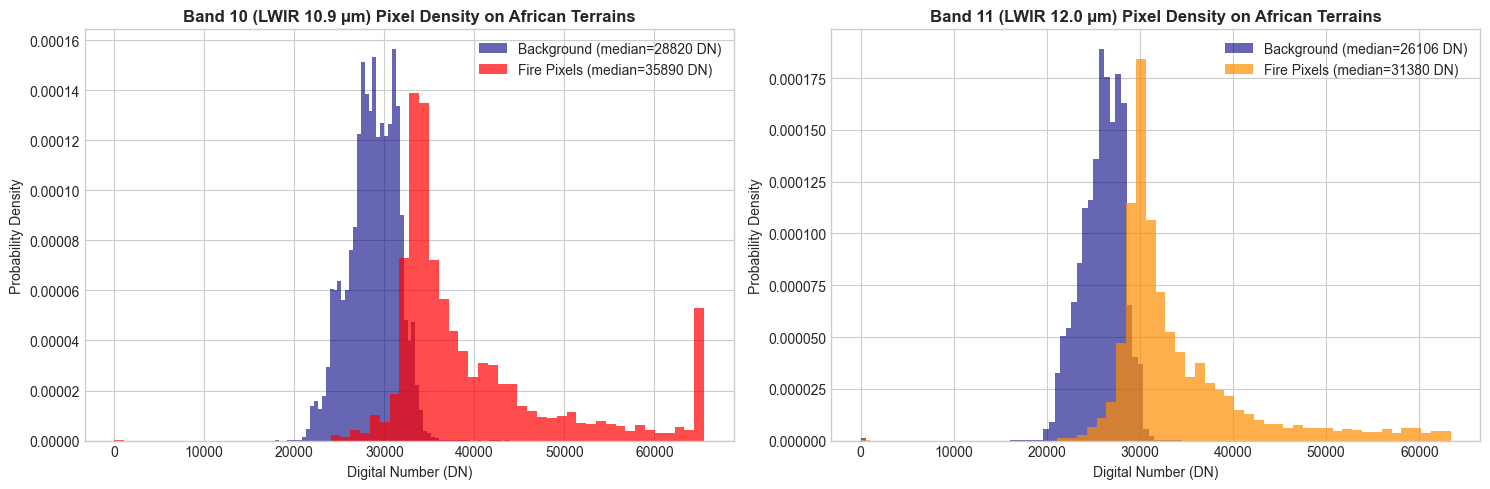

In [5]:
from fireedge.exploration import band_separability_report

channel_map = {"B6 (SWIR 1)": 5, "B7 (SWIR 2)": 6, "B10 (LWIR 1)": 8, "B11 (LWIR 2)": 9}
fire_samples = {b: [] for b in channel_map}
bg_samples = {b: [] for b in channel_map}

masked_patches = df_africa[df_africa["has_mask"]]
if len(masked_patches) == 0:
    print("WARNING: No fire patches found. Skipping separability analysis.")
else:
    for _, row in masked_patches.iterrows():
        p_img = read_image(row["image_path"])
        p_mask = read_mask(row["mask_path"], shape=p_img.shape[1:]) > 0
        bg_m = ~p_mask & (p_img[min(8, p_img.shape[0]-1)] > 0)
        for b_name, c_idx in channel_map.items():
            if c_idx < p_img.shape[0]:
                f_pix = p_img[c_idx][p_mask]
                b_pix = p_img[c_idx][bg_m]
                if len(f_pix) > 0:
                    fire_samples[b_name].append(f_pix)
                if len(b_pix) > 0:
                    bg_samples[b_name].append(b_pix[::50])  # Subsample background

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Band 10 Distribution
    b10_f = np.concatenate(fire_samples["B10 (LWIR 1)"])
    b10_bg = np.concatenate(bg_samples["B10 (LWIR 1)"])

    axes[0].hist(b10_bg, bins=60, density=True, alpha=0.6, color="navy", label=f"Background (median={np.median(b10_bg):.0f} DN)")
    axes[0].hist(b10_f, bins=60, density=True, alpha=0.7, color="red", label=f"Fire Pixels (median={np.median(b10_f):.0f} DN)")
    axes[0].set_title("Band 10 (LWIR 10.9 µm) Pixel Density on African Terrains", fontsize=12, weight='bold')
    axes[0].set_xlabel("Digital Number (DN)")
    axes[0].set_ylabel("Probability Density")
    axes[0].legend()

    # Band 11 Distribution
    b11_f = np.concatenate(fire_samples["B11 (LWIR 2)"])
    b11_bg = np.concatenate(bg_samples["B11 (LWIR 2)"])

    axes[1].hist(b11_bg, bins=60, density=True, alpha=0.6, color="navy", label=f"Background (median={np.median(b11_bg):.0f} DN)")
    axes[1].hist(b11_f, bins=60, density=True, alpha=0.7, color="darkorange", label=f"Fire Pixels (median={np.median(b11_f):.0f} DN)")
    axes[1].set_title("Band 11 (LWIR 12.0 µm) Pixel Density on African Terrains", fontsize=12, weight='bold')
    axes[1].set_xlabel("Digital Number (DN)")
    axes[1].set_ylabel("Probability Density")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Print ROC-AUC Metrics
    samples_dict = {
        "B10": (b10_f, b10_bg),
        "B11": (b11_f, b11_bg),
    }
    if fire_samples["B7 (SWIR 2)"] and bg_samples["B7 (SWIR 2)"]:
        samples_dict["B7"] = (np.concatenate(fire_samples["B7 (SWIR 2)"]), np.concatenate(bg_samples["B7 (SWIR 2)"]))
    
    report_df = band_separability_report(samples_dict)
    print("=== African Separability Summary ===")
    display(report_df)

## 4. Gate 1 Validation: Ground Mode vs. Flight Mode
In this section, we run the **Dual-Gate Input Validator** directly on a raw frame:
1. **Ground Mode (`GroundGateValidator`)**: Cross-checks hot pixels between Band 10 and Band 11.
2. **Flight Mode (`FlightGateValidator`)**: Analyzes single-band Point Spread Function (PSF) Spatial Halo Ratio to differentiate cosmic ray radiation (SEU) hits from real sub-pixel optical fires.


In [6]:
if len(fire_patches) > 0:
    # Calibrate a standard 16-bit configuration
    b10_cfg = ValidatorConfig(bit_depth=16, valid_min=15000, valid_max=50000, noise_flag=5.0, noise_reject=15.0)
    b11_cfg = ValidatorConfig(bit_depth=16, valid_min=15000, valid_max=45000, noise_flag=5.0, noise_reject=15.0)

    # Instantiate validators
    ground_val = GroundGateValidator([b10_cfg, b11_cfg])
    flight_val = FlightGateValidator(b10_cfg, halo_threshold=0.15)

    # Validate sample
    dual_band_img = img[[b10_idx, b11_idx]]  # B10, B11
    single_band_img = img[[b10_idx]]           # B10 only

    rep_ground = ground_val.validate(dual_band_img)
    rep_flight = flight_val.validate(single_band_img)

    print("=== Gate 1 Validation Verdicts ===")
    print(f"Ground Mode Verdict: {rep_ground.status.value}")
    print(f"  Reasons: {rep_ground.reasons}")
    print(f"  B10 confirmed anomalies: {rep_ground.metrics.get('ch0.hot_confirmed_real', 0)}")
    print()
    print(f"Flight Mode Verdict: {rep_flight.status.value}")
    print(f"  Reasons: {rep_flight.reasons}")
    print(f"  Confirmed Optical Hotspots: {rep_flight.metrics.get('ch0.hot_confirmed_optical', 0)}")
    print(f"  Radiation SEU Transients Filtered: {rep_flight.metrics.get('ch0.seu_transients', 0)}")
else:
    print("Skipping validation — no fire patches loaded.")

=== Gate 1 Validation Verdicts ===
Ground Mode Verdict: PASS_WITH_FLAGS
  Reasons: ['ch0:STRIPING', 'ch0:HOT_PIXELS', 'ch1:STRIPING', 'ch1:HOT_PIXELS']
  B10 confirmed anomalies: 10

Flight Mode Verdict: PASS_WITH_FLAGS
  Reasons: ['ch0:STRIPING']
  Confirmed Optical Hotspots: 8467
  Radiation SEU Transients Filtered: 0


## 5. Dataset Quality Summary
Overview of all African patches: mask coverage, band dimensions, and patch health.


In [7]:
from fireedge.preprocessing.calibration import dn_to_temperature

print("=== Dataset Quality Summary ===")
print(f"Total patches:       {len(df_africa)}")
print(f"Patches with mask:   {df_africa['has_mask'].sum()}")
print(f"Patches without:     {(~df_africa['has_mask']).sum()}")
print(f"Unique scenes:       {df_africa['scene_id'].nunique()}")
print(f"Date range:          {df_africa['date'].min()} to {df_africa['date'].max()}")

# Quick calibration sanity check on a single patch
if len(fire_patches) > 0:
    sample_b10 = img[b10_idx]
    temp_k = dn_to_temperature(sample_b10, band="B10", unit="kelvin")
    valid = temp_k[temp_k > 200]  # filter out nodata
    print(f"\n--- Calibration Sanity Check (sample patch) ---")
    print(f"  B10 DN range: [{sample_b10.min()}, {sample_b10.max()}]")
    print(f"  B10 Temperature (K): min={valid.min():.1f}, max={valid.max():.1f}, mean={valid.mean():.1f}")
    print(f"  B10 Temperature (°C): min={valid.min()-273.15:.1f}, max={valid.max()-273.15:.1f}, mean={valid.mean()-273.15:.1f}")

print("\n✅ EDA notebook complete.")

=== Dataset Quality Summary ===
Total patches:       44
Patches with mask:   44
Patches without:     0
Unique scenes:       44
Date range:          20200806 to 20200916

--- Calibration Sanity Check (sample patch) ---
  B10 DN range: [26412, 34196]
  B10 Temperature (K): min=295.2, max=312.9, mean=298.9
  B10 Temperature (°C): min=22.1, max=39.7, mean=25.8

✅ EDA notebook complete.
